In [1]:
import sys
sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras
import time 

import bayesflow as bf
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


arguments = sys.argv[1:]

if 'executed_from_bash' in arguments:
    network_name_fixed = str(arguments[0])
    host = str(arguments[1])
    fixed_n_obs = int(arguments[2])
    num_resims = int(arguments[6])
    network_name_estimated = str(arguments[3])

else:
    network_name_fixed = 'updated_priors_sdr_fixed'
    network_name_estimated = 'updated_priors_sdr_estimated'
    fixed_n_obs = 300
    num_resims = 100
    host = 'local'


parent_dir = os.path.dirname(os.getcwd())

print(f'parent_dir: {parent_dir}', flush=True)


from dmc import DMC, dmc_helpers

data_path = parent_dir + '/data_complete/ppc_data'

if not os.path.exists(data_path):
      os.makedirs(data_path)

train_idx = np.array([1761, 5281,  845, 1824, 5575, 8755, 8026, 8704, 7813, 1597, 7756,
       7624, 1108,  837, 7828, 6055,  833, 1821,  985, 1582, 8311, 8785,
       3286, 4264, 6583, 3487, 6427, 1430, 6361, 5815, 6262, 5332,
       1614, 7939, 6214])




INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


parent_dir: /home/administrator/Documents/amortized-dmc


## Load PPC data

Before running this script, please make sure to compute empirical estimates (scripts/empirical_estimates.py) and posterior predictive resimulations (scripts/posterior_predictive_check_data.py)

In [2]:
df_complete = pd.read_csv(data_path + '/ppc_data_raw_' + network_name_fixed + '.csv')

# exclude all non-convergents:

df_complete = df_complete[df_complete['rt'] != -1]

Load empirical data

In [3]:

narrow_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_narrow.csv')
wide_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_wide.csv')

empirical_data = pd.concat([narrow_data, wide_data])

empirical_data["condition_label"] = empirical_data["congruency_num"].map({0.0: "congruent", 1.0: "incongruent"})

empirical_data["spacing"] = empirical_data["spacing_num"].map({0.0: "wide", 1.0: "narrow"})


In [4]:
id_name = 'participant'

congruency_name = 'condition_label'

alpha = 0.0

n_delta_bins = 10

n_rt_bins = 5


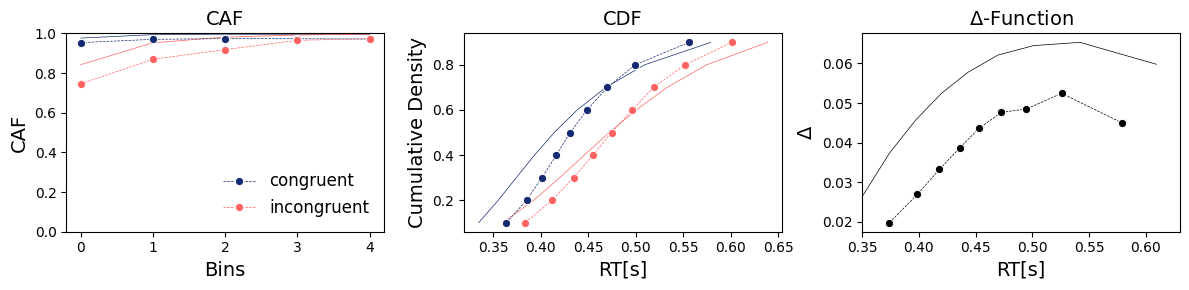

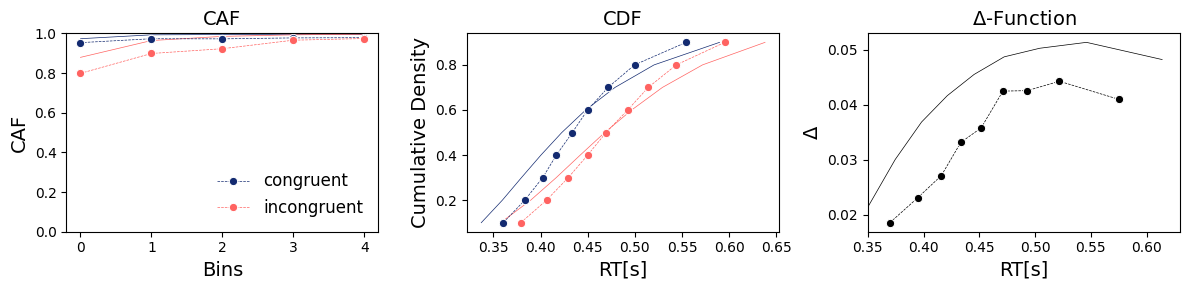

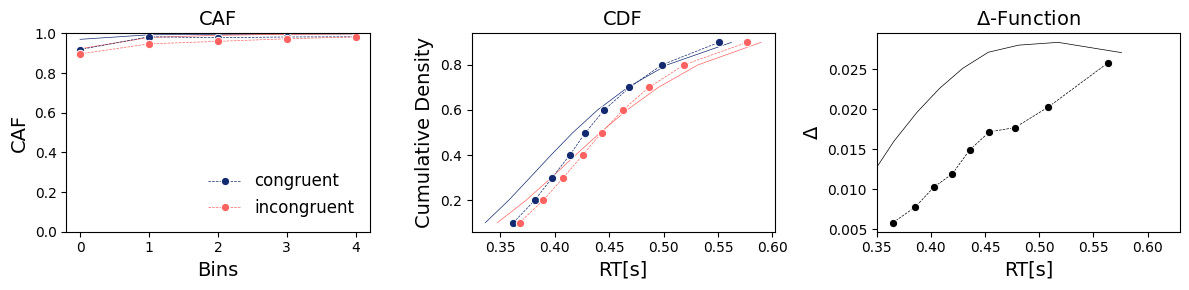

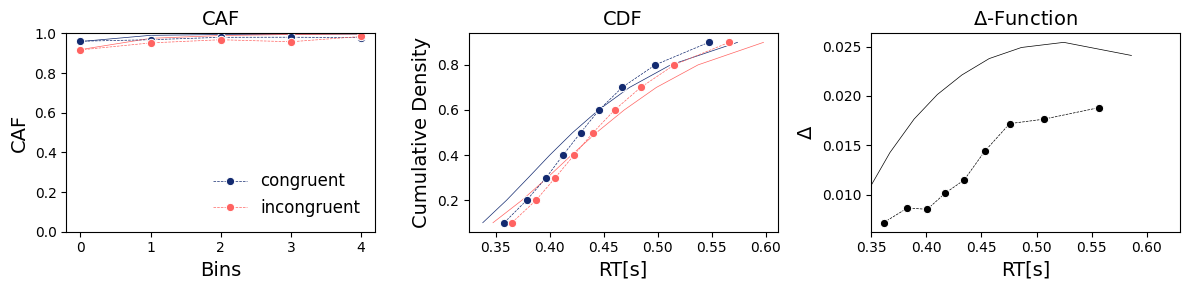

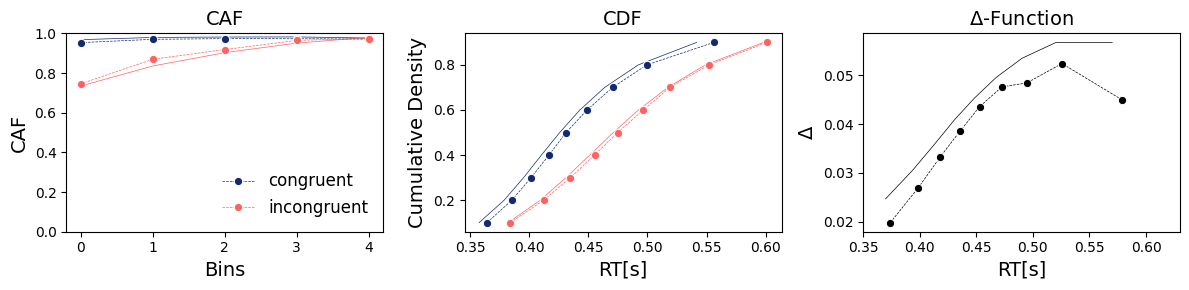

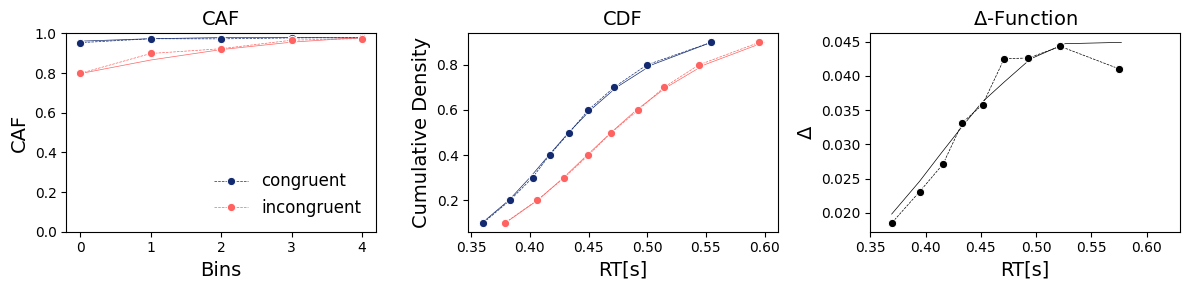

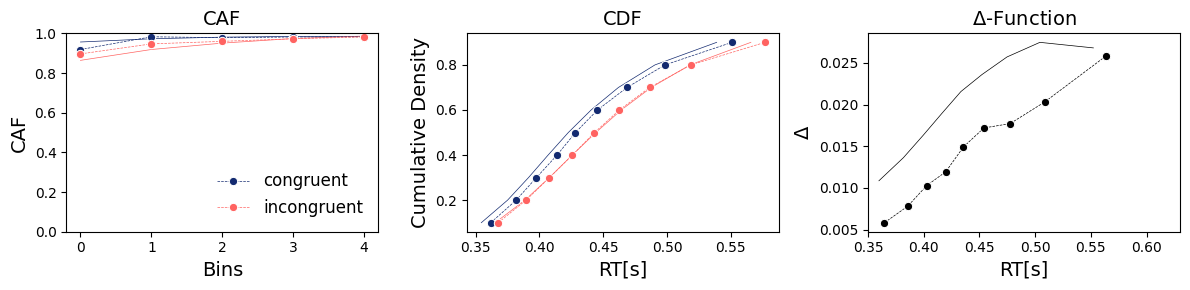

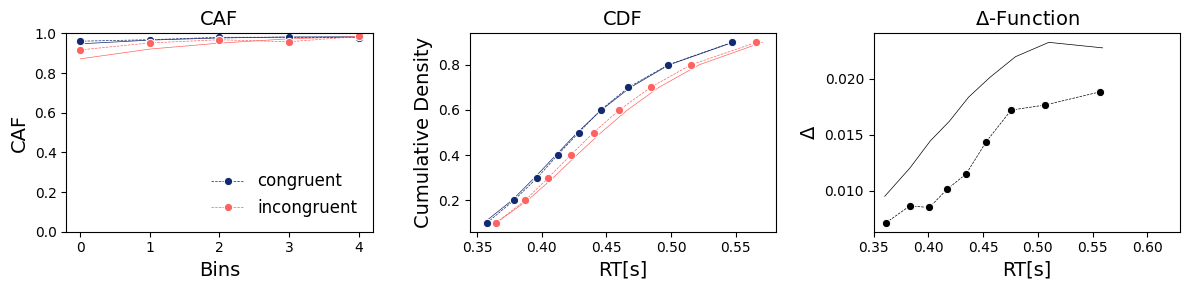

In [5]:
for model in [network_name_fixed,network_name_estimated]:

    for spacing in ['narrow', 'wide']:

        for data_split in ['train', 'test']:

            # RESIMULATIONS: filter data -> select model - spacing - data set condition
            data_model = df_complete[df_complete['model'] == model]

            data_model = data_model[data_model['spacing'] == spacing]

            if data_split == 'train':
                data_model = data_model[data_model['participant'].isin(train_idx)]
            else:
                data_model = data_model[~data_model['participant'].isin(train_idx)]

            # compute aggregated data sets
            caf_resim, cdf_resim, delta_resim = dmc_helpers.compute_stats(df_complete=data_model, id_name=id_name, congruency_name=congruency_name)

            # EMPIRICAL DATA: filter data -> select model - spacing - data set condition
            data_emp = empirical_data[empirical_data['spacing'] == spacing]

            if data_split == 'train':
                data_emp = data_emp[data_emp['participant'].isin(train_idx)]
            else:
                data_emp = data_emp[~data_emp['participant'].isin(train_idx)]

            # compute aggregated data sets
            caf_emp, cdf_emp, delta_emp = dmc_helpers.compute_stats(df_complete=data_emp, id_name=id_name, congruency_name=congruency_name)

            # plot model fit (resimulation vs. empirical data)
            fig, axes = dmc_helpers.plot_fit(delta_data=delta_resim,
                                             delta_data_emp=delta_emp,
                                             caf_data=caf_resim,
                                             caf_data_emp=caf_emp,
                                             cdf_data=cdf_resim,
                                             cdf_data_emp=cdf_emp,
                                             congruency_name='condition_label',
                                             congruency_name_emp='condition_label')
